In [1]:
from fashion_detector.utils import (
    load_image,
    visualize_detections,
    user_categories,
    mapped_user_categories,
    execute_detection,
    clean_categories,
    display_imageGrid
)
from fashion_detector import FastBoxFashionPipeline
from fashion_detector.config import Config

In [2]:
# Initialize New Fast Box Pipeline
config = Config()
pipeline = FastBoxFashionPipeline(config=config, max_detection_size=640)

# Pre-load models & pre-cache text embeddings
pipeline.load_models()

[2026-07-24 22:17:29] [INFO] [fashion_detector:config.py:179] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-24 22:17:29] [INFO] [fashion_detector:box_pipeline.py:154] - Warming up FastBoxFashionPipeline models (Grounding DINO, FashionCLIP)...
[2026-07-24 22:17:29] [INFO] [fashion_detector:grounding_dino.py:33] - Loading Grounding DINO model: openmmlab-community/mm_grounding_dino_base_all on device: mps


Loading weights:   0%|          | 0/1219 [00:00<?, ?it/s]

[2026-07-24 22:17:36] [INFO] [fashion_detector:grounding_dino.py:46] - Grounding DINO model loaded successfully.
[2026-07-24 22:17:36] [INFO] [fashion_detector:fashion_clip.py:33] - Loading FashionCLIP model: patrickjohncyh/fashion-clip on device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[2026-07-24 22:17:41] [INFO] [fashion_detector:fashion_clip.py:46] - FashionCLIP model loaded successfully.
[2026-07-24 22:17:41] [INFO] [fashion_detector:box_pipeline.py:166] - Pre-caching vectorized FashionCLIP text embeddings...
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.3057 seconds
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0955 seconds
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0509 seconds
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embed

[2026-07-24 22:17:41] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-2.jpeg
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:41] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:43] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 7 items.
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.7585 seconds
[2026-07-24 22:17:43] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 7 raw proposals, reduced to 7 after NMS.
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.7600 seconds
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:103] - Complete

/Users/sunnyraj/code_files/git_repos/image-segments/sam3_venv/.venv/lib/python3.12/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



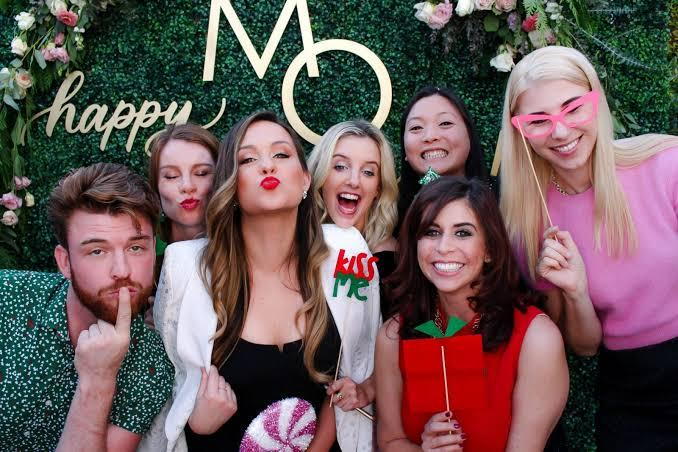

In [3]:
import os
images_folder = 'data/input_images/'
sample_images = [f"{images_folder}{i}" for i in os.listdir(images_folder)]
test_image_path = 'data/input_images/images-2.jpeg'

# Process image in ultra-fast Box-Only Mode (~200ms latency)
result = pipeline.process(test_image_path, include_masks=False)

print(f"Total Objects Detected: {result.total_objects}")
print(f"Pipeline Total Time: {result.processing_time_ms} ms")

for obj in result.objects:
    print(f"- {obj.label} ({obj.broad_category} -> {obj.subcategory}): score={obj.score:.2f}, box={obj.box}")
visualize_detections(result.processed_image, result.objects)

[2026-07-24 22:17:43] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-30.jpeg
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:43] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:45] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 5 items.
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.5152 seconds
[2026-07-24 22:17:45] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 5 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.5171 seconds
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:103] - Complet


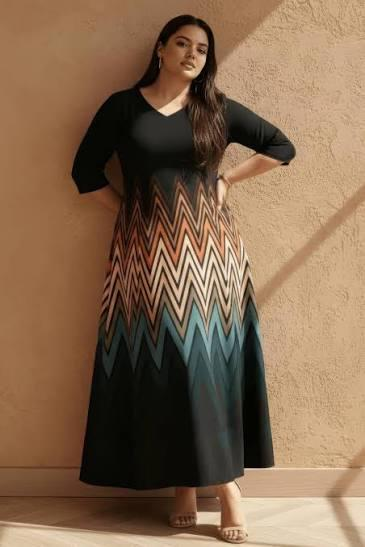

[2026-07-24 22:17:45] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-26.jpeg
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:45] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:46] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 1 items.
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3854 seconds
[2026-07-24 22:17:46] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 1 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3864 seconds
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:103] - Complet


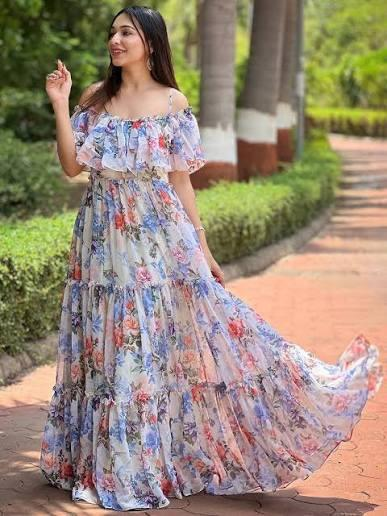

[2026-07-24 22:17:46] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-3.jpeg
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:46] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:48] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 12 items.
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.6543 seconds
[2026-07-24 22:17:48] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 12 raw proposals, reduced to 11 after NMS.
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.6557 seconds
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:103] - Compl


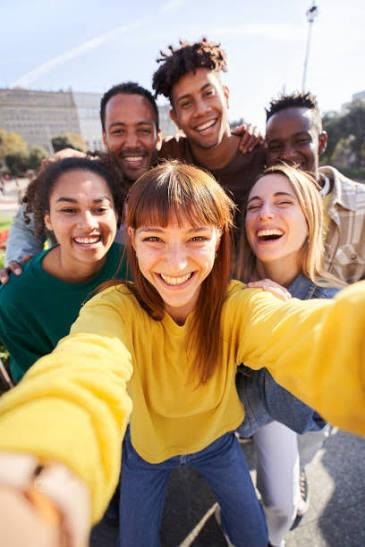

[2026-07-24 22:17:48] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-10.jpeg
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:48] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:49] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 1 items.
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2948 seconds
[2026-07-24 22:17:49] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 1 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2956 seconds
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:103] - Complet


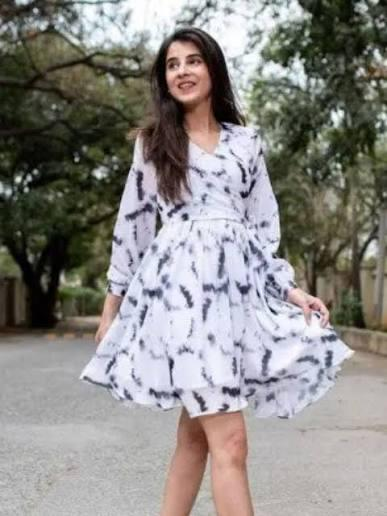

[2026-07-24 22:17:49] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-11.jpeg
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:49] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:50] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2674 seconds
[2026-07-24 22:17:50] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2682 seconds
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:103] - Complet


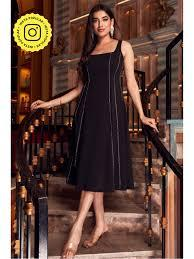

[2026-07-24 22:17:50] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images.jpeg
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:50] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:52] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 11 items.
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3447 seconds
[2026-07-24 22:17:52] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 11 raw proposals, reduced to 11 after NMS.
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3454 seconds
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:103] - Complet


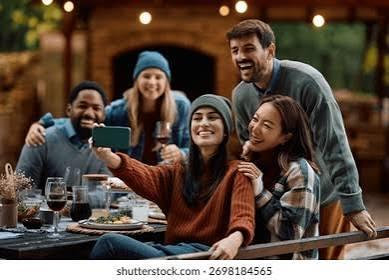

[2026-07-24 22:17:52] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-2.jpeg
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:52] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:53] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 7 items.
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.5028 seconds
[2026-07-24 22:17:53] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 7 raw proposals, reduced to 7 after NMS.
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.5035 seconds
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:103] - Complete


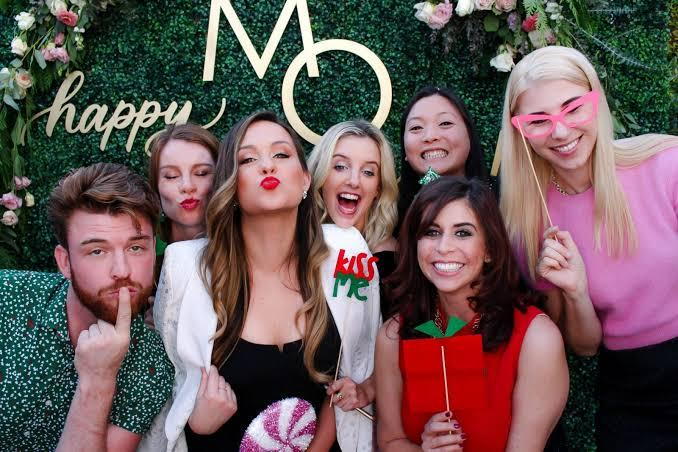

[2026-07-24 22:17:53] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/casual_wear_men.jpg
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:53] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:55] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3877 seconds
[2026-07-24 22:17:55] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3884 seconds
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:103] - Co


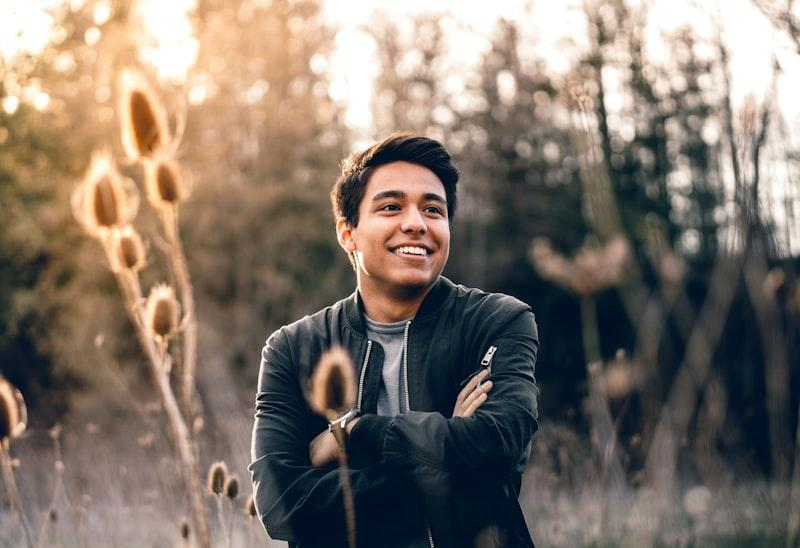

[2026-07-24 22:17:55] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-27.jpeg
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:55] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:56] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2565 seconds
[2026-07-24 22:17:56] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2571 seconds
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:103] - Complet


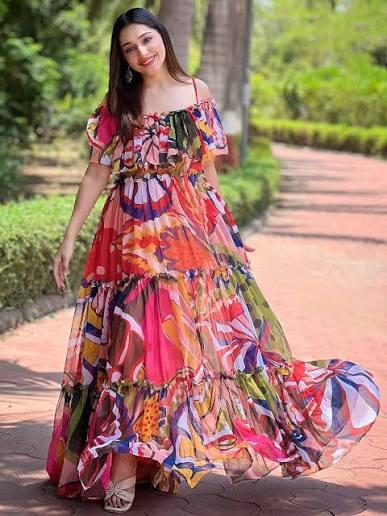

[2026-07-24 22:17:56] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-31.jpeg
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:56] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:57] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2553 seconds
[2026-07-24 22:17:57] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2560 seconds
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:103] - Complet


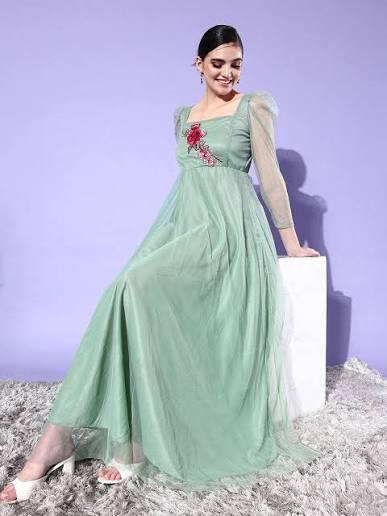

[2026-07-24 22:17:57] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-5.jpeg
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:57] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:17:59] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 8 items.
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2585 seconds
[2026-07-24 22:17:59] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 8 raw proposals, reduced to 8 after NMS.
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2593 seconds
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:103] - Complete


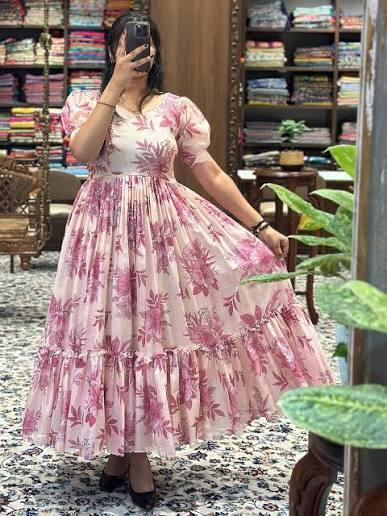

[2026-07-24 22:17:59] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-16.jpeg
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:17:59] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:00] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2530 seconds
[2026-07-24 22:18:00] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2537 seconds
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:103] - Complet


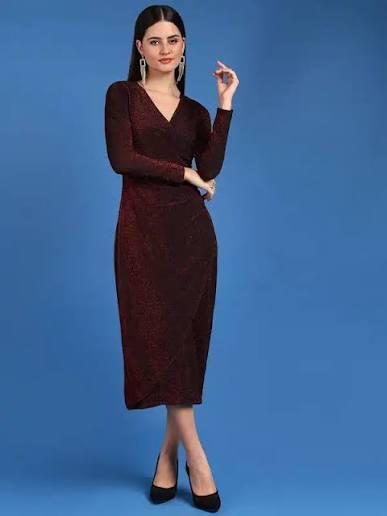

[2026-07-24 22:18:00] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-36.jpeg
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:00] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:02] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4078 seconds
[2026-07-24 22:18:02] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4083 seconds
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:103] - Complet


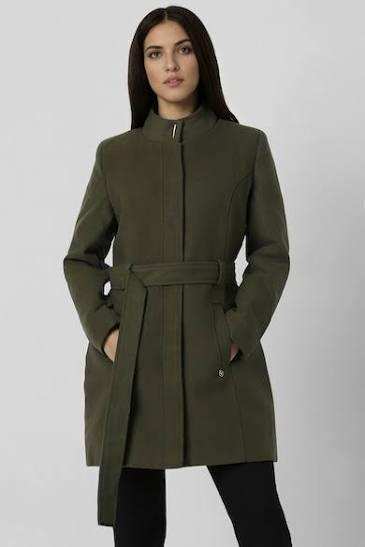

[2026-07-24 22:18:02] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/Unknown.jpg
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:02] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:03] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2590 seconds
[2026-07-24 22:18:03] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2597 seconds
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:103] - Completed:


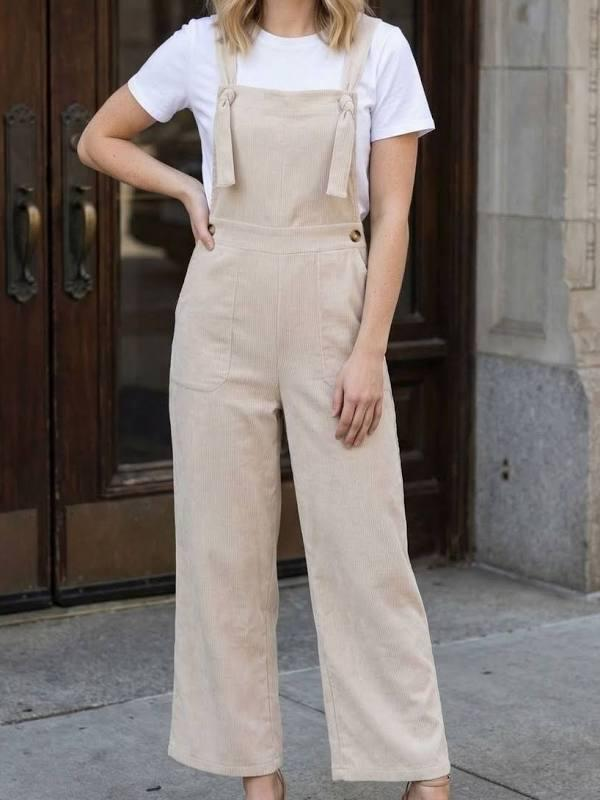

[2026-07-24 22:18:03] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-9.jpeg
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:03] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:04] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4040 seconds
[2026-07-24 22:18:04] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4047 seconds
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:103] - Complete


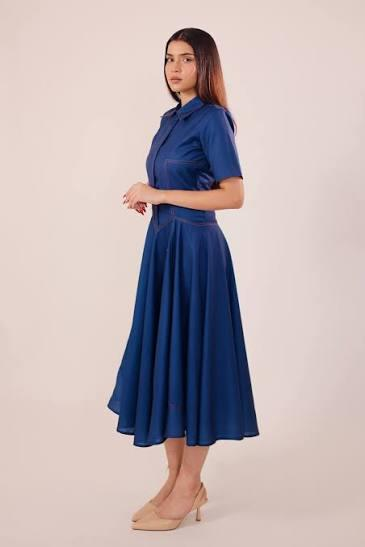

[2026-07-24 22:18:04] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-20.jpeg
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:04] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:06] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4082 seconds
[2026-07-24 22:18:06] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4098 seconds
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:103] - Complet


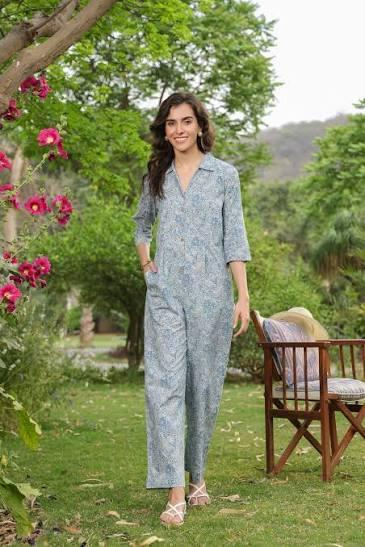

[2026-07-24 22:18:06] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-21.jpeg
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:06] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:07] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 1 items.
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3965 seconds
[2026-07-24 22:18:07] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 1 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3973 seconds
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:103] - Complet


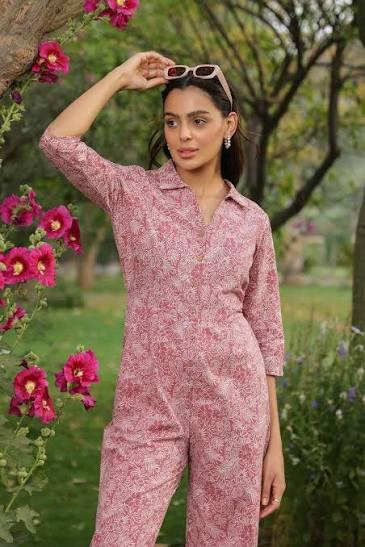

[2026-07-24 22:18:07] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-8.jpeg
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:07] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:08] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:08] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2909 seconds
[2026-07-24 22:18:08] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:08] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2917 seconds
[2026-07-24 22:18:08] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:08] [INFO] [fashion_detector:logging.py:103] - Complete


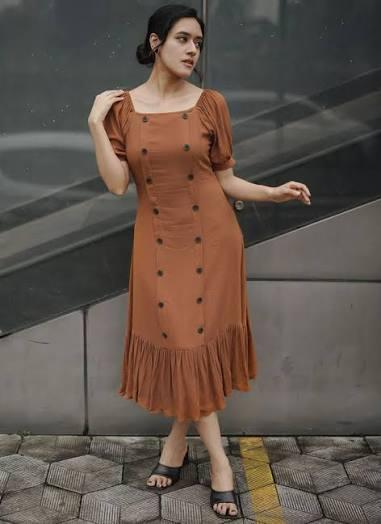

[2026-07-24 22:18:09] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-17.jpeg
[2026-07-24 22:18:09] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:09] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:10] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4183 seconds
[2026-07-24 22:18:10] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4189 seconds
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:103] - Complet


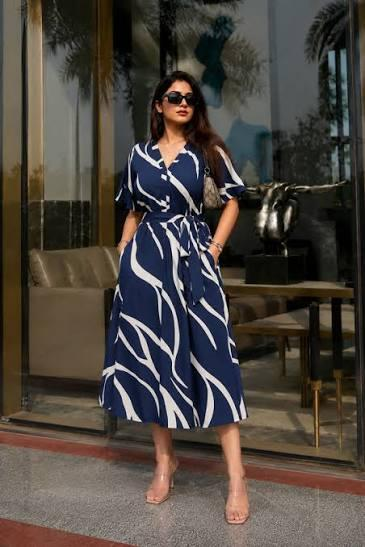

[2026-07-24 22:18:10] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-4.jpeg
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:10] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:11] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4018 seconds
[2026-07-24 22:18:11] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4025 seconds
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:103] - Complete


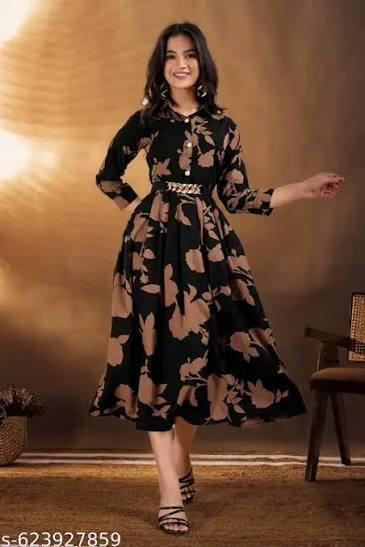

[2026-07-24 22:18:11] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-14.jpeg
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:11] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:13] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 1 items.
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2034 seconds
[2026-07-24 22:18:13] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 1 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2042 seconds
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:103] - Complet


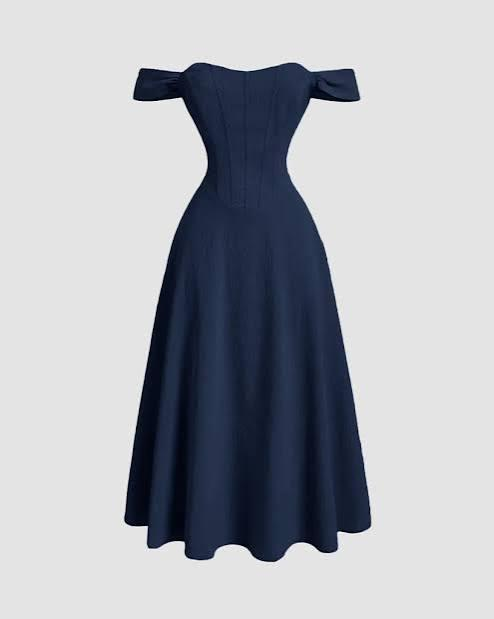

[2026-07-24 22:18:13] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/multiple_people.jpg
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:13] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:14] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 12 items.
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4552 seconds
[2026-07-24 22:18:14] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 12 raw proposals, reduced to 11 after NMS.
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4560 seconds
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:103] -


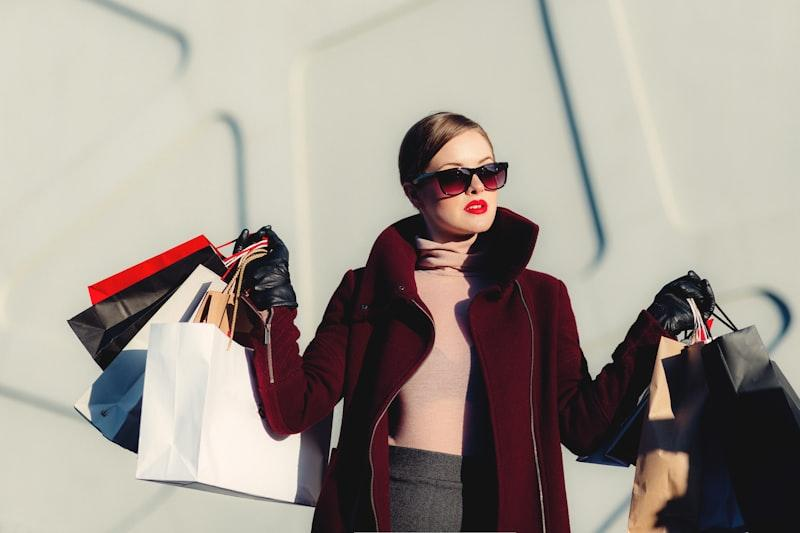

[2026-07-24 22:18:14] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-7.jpeg
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:14] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:16] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4007 seconds
[2026-07-24 22:18:16] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4018 seconds
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:103] - Complete


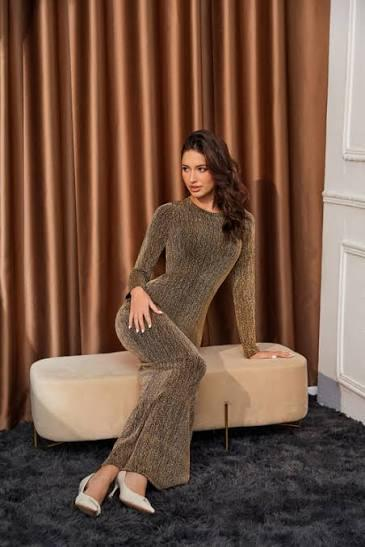

[2026-07-24 22:18:16] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-18.jpeg
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:16] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:17] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3923 seconds
[2026-07-24 22:18:17] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3931 seconds
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:103] - Complet


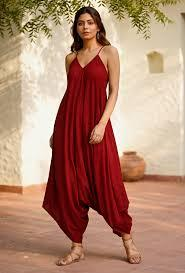

[2026-07-24 22:18:17] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-22.jpeg
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:17] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:19] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.9037 seconds
[2026-07-24 22:18:19] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.9058 seconds
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:103] - Complet


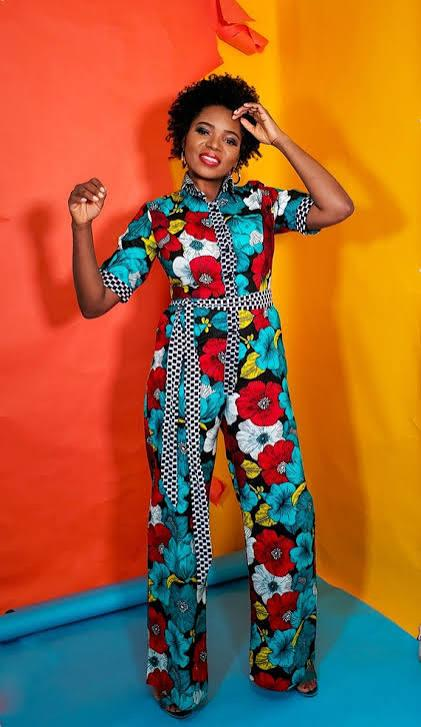

[2026-07-24 22:18:19] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-34.jpeg
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:19] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:20] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2736 seconds
[2026-07-24 22:18:20] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2744 seconds
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:103] - Complet


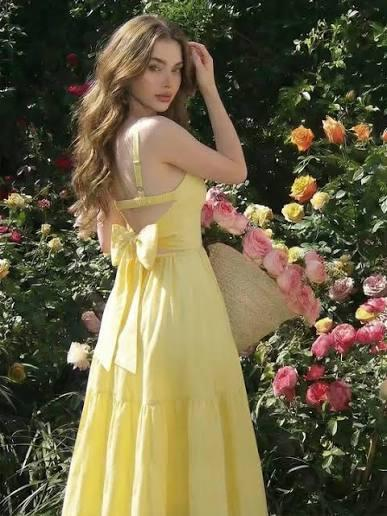

[2026-07-24 22:18:20] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-35.jpeg
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:20] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:22] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2594 seconds
[2026-07-24 22:18:22] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2603 seconds
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:103] - Complet


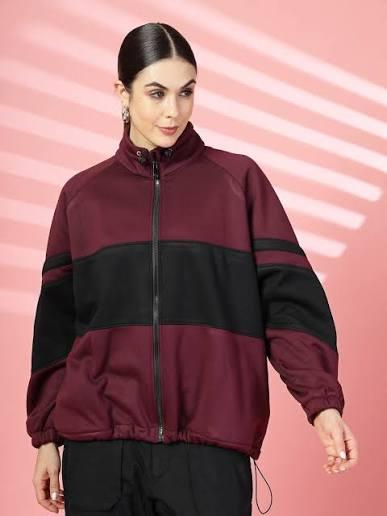

[2026-07-24 22:18:22] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-23.jpeg
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:22] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:23] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4593 seconds
[2026-07-24 22:18:23] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4606 seconds
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:103] - Complet


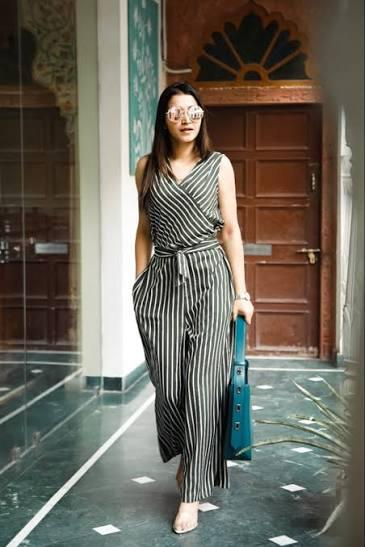

[2026-07-24 22:18:23] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-19.jpeg
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:23] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:24] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:24] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2619 seconds
[2026-07-24 22:18:24] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:24] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2628 seconds
[2026-07-24 22:18:24] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:24] [INFO] [fashion_detector:logging.py:103] - Complet


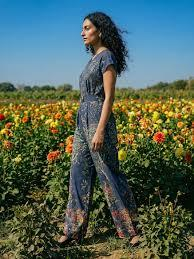

[2026-07-24 22:18:25] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-6.jpeg
[2026-07-24 22:18:25] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:25] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:26] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2002 seconds
[2026-07-24 22:18:26] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2010 seconds
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:103] - Complete


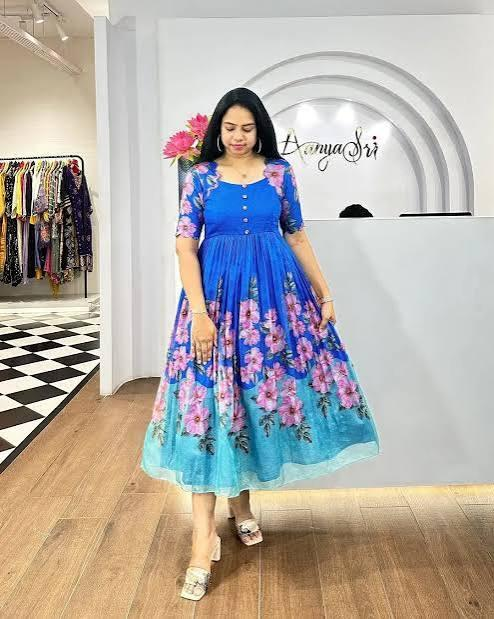

[2026-07-24 22:18:26] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-15.jpeg
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:26] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:27] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2577 seconds
[2026-07-24 22:18:27] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2584 seconds
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:103] - Complet


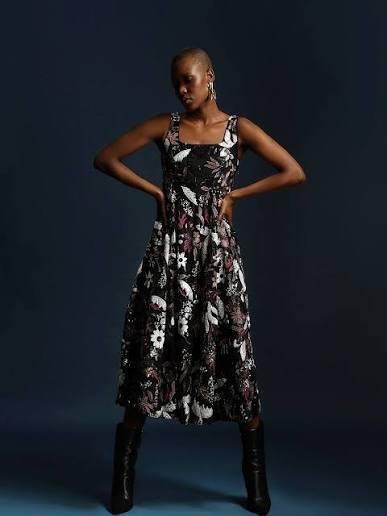

[2026-07-24 22:18:27] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/fashion_model_street.jpg
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:27] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:28] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 5 items.
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2996 seconds
[2026-07-24 22:18:28] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 5 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3003 seconds
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:103]


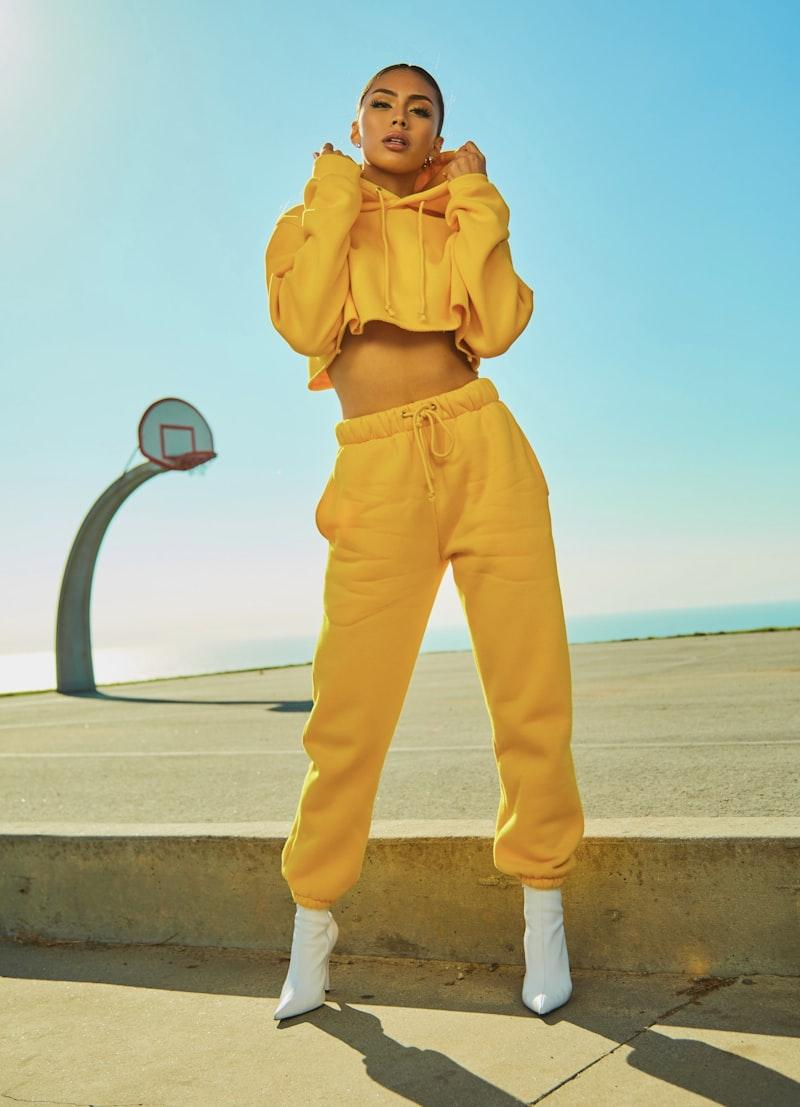

[2026-07-24 22:18:28] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-24.jpeg
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:28] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:30] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2786 seconds
[2026-07-24 22:18:30] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2799 seconds
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:103] - Complet


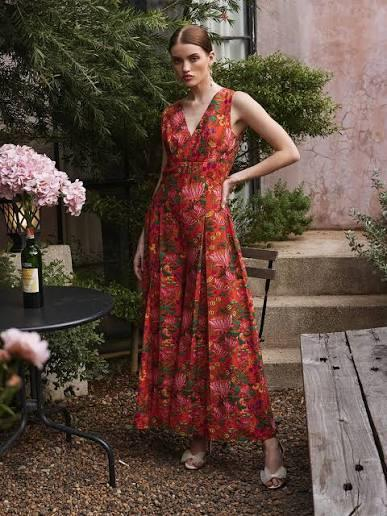

[2026-07-24 22:18:30] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-32.jpeg
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:30] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:31] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2597 seconds
[2026-07-24 22:18:31] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2606 seconds
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:103] - Complet


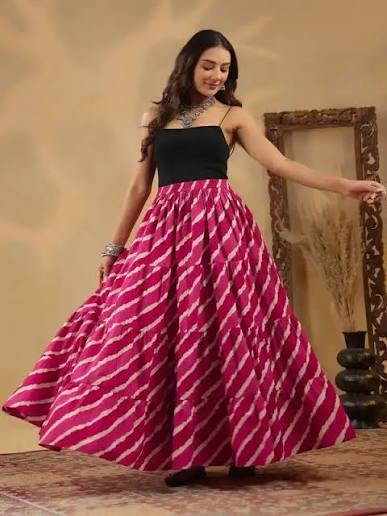

[2026-07-24 22:18:31] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-12.jpeg
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:31] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:32] [INFO] [fashion_detector:grounding_dino.py:151] - Filtering out small box 'foot' with area 166.9 pixels (min threshold: 263.5)
[2026-07-24 22:18:32] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 1 items.
[2026-07-24 22:18:32] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3227 seconds
[2026-07-24 22:18:32] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 1 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:18:32] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3234 seconds
[2026-07-24 22:18:32] [I


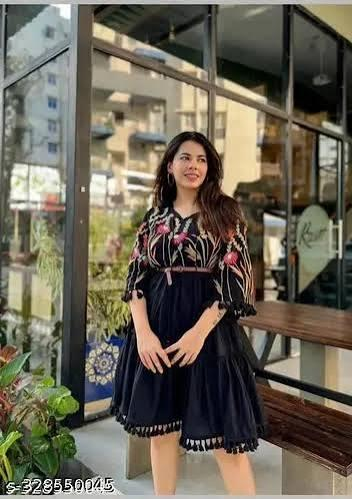

[2026-07-24 22:18:32] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-28.jpeg
[2026-07-24 22:18:32] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:32] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:34] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.1994 seconds
[2026-07-24 22:18:34] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 2 after NMS.
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2004 seconds
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:103] - Complet


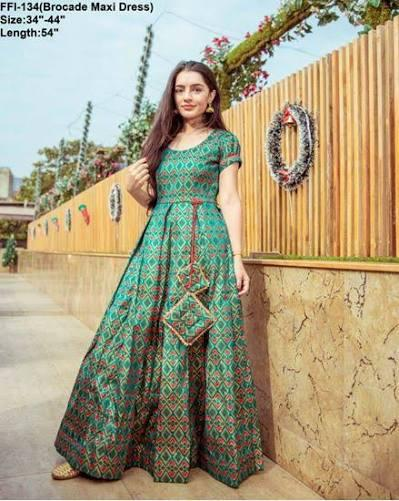

[2026-07-24 22:18:34] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-29.jpeg
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:34] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:35] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.2563 seconds
[2026-07-24 22:18:35] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.2570 seconds
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:103] - Complet


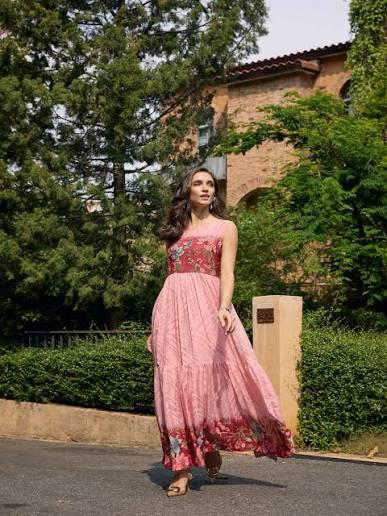

[2026-07-24 22:18:35] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-13.jpeg
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:35] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:36] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 3 items.
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.0667 seconds
[2026-07-24 22:18:36] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 3 raw proposals, reduced to 3 after NMS.
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.0679 seconds
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:103] - Complet


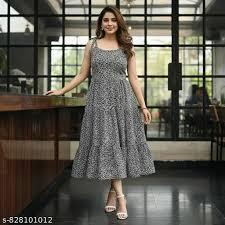

[2026-07-24 22:18:36] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-33.jpeg
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:36] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:37] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:37] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3408 seconds
[2026-07-24 22:18:37] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:37] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3416 seconds
[2026-07-24 22:18:37] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:37] [INFO] [fashion_detector:logging.py:103] - Complet


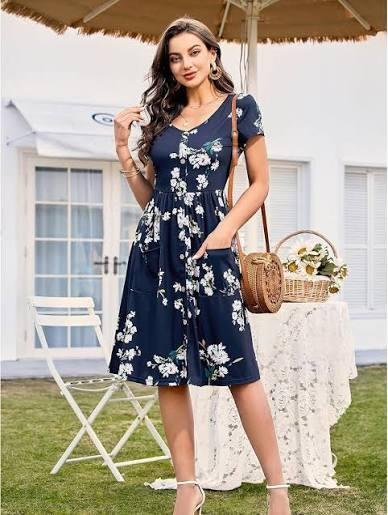

[2026-07-24 22:18:38] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/images-25.jpeg
[2026-07-24 22:18:38] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:38] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:39] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 4 items.
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.4339 seconds
[2026-07-24 22:18:39] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.4350 seconds
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:103] - Complet


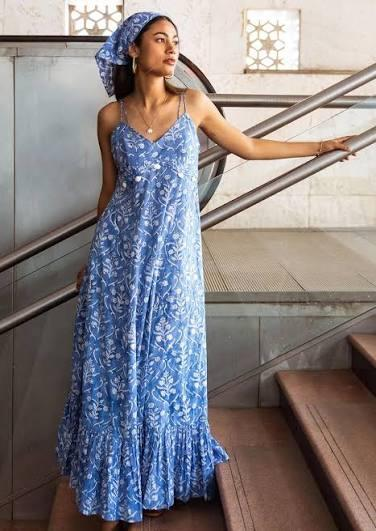

[2026-07-24 22:18:39] [INFO] [fashion_detector:utils.py:201] - Loading image from local path: data/input_images/accessories_social.jpg
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 22:18:39] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 22:18:41] [INFO] [fashion_detector:grounding_dino.py:165] - Grounding DINO detected 2 items.
[2026-07-24 22:18:41] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.5160 seconds
[2026-07-24 22:18:41] [INFO] [fashion_detector:box_pipeline.py:261] - Batched Grounding DINO detected 2 raw proposals, reduced to 1 after NMS.
[2026-07-24 22:18:41] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.5172 seconds
[2026-07-24 22:18:41] [INFO] [fashion_detector:logging.py:98] - Starting: Direct Box Crop Extraction
[2026-07-24 22:18:41] [INFO] [fashion_detector:logging.py:103] -


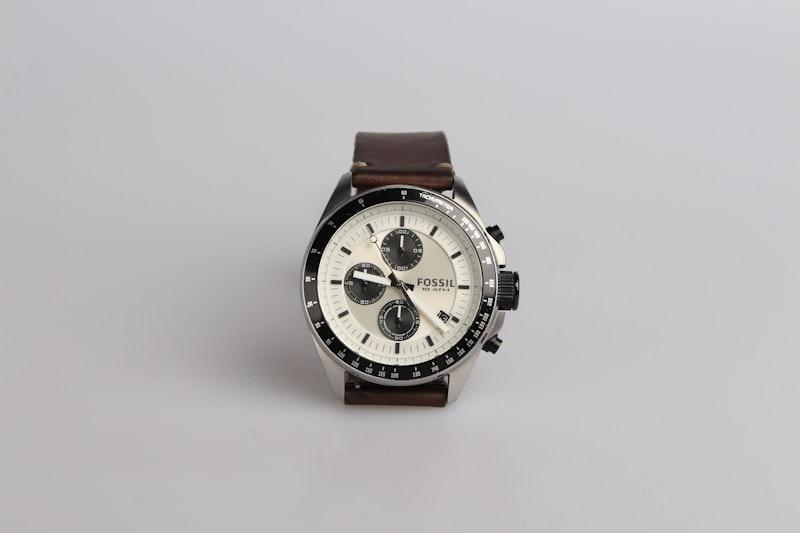

In [4]:
from pathlib import Path
new_folder = Path("data/out_image")
for test_image_path in sample_images:# Process image in ultra-fast Box-Only Mode (~200ms latency)
    result = pipeline.process(test_image_path, include_masks=False)
    filename = Path(test_image_path).name
    new_full_path = new_folder / filename 
    result.annotated_image.save(new_full_path)
    visualize_detections(result.processed_image, result.objects)